# Pràctica 4 – Part 2A: Avaluació Intrínseca (Multi-SimLex)
Comparem els models entrenats (Word2Vec, FastText) i el FastText oficial contra les puntuacions humanes de Multi-SimLex en espanyol.
**Mètrica**: correlació de Spearman entre similitud cosinus del model i puntuació humana.

## 1. Imports

In [13]:
import numpy as np
from gensim.models import KeyedVectors
import pickle
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.stats import spearmanr
from sklearn.metrics.pairwise import cosine_similarity
from gensim.models import Word2Vec, FastText as GensimFastText

MODELS_DIR = Path("models")

## 2. Llegir Multi-SimLex
El CSV té una columna per cada anotador. Fem la mitjana per obtenir el score final.

In [22]:
simlex = pd.read_csv("SPA.csv")

# Columnes d'anotadors (totes les que no són metadades)
META_COLS   = ["ID", "Word 1", "Word 2", "PoS"]
ANNOT_COLS  = [c for c in simlex.columns if c not in META_COLS]

simlex["score"] = simlex[ANNOT_COLS].mean(axis=1) / 6.0
simlex["w1"]    = simlex["Word 1"].str.lower()
simlex["w2"]    = simlex["Word 2"].str.lower()
simlex          = simlex[["w1", "w2", "score"]].dropna()

print(f"Parelles: {len(simlex)}")
print(simlex.head(5))

Parelles: 1888
           w1         w2     score
0       brazo    músculo  0.233333
1  democracia  monarquía  0.216667
2      tejado      techo  0.800000
3       amigo   profesor  0.066667
4        mano        pie  0.183333


## 3. Càrrega dels models entrenats

In [11]:
# Carrega tots els models des del pkl d'entrenament
with open(MODELS_DIR / "results.pkl", "rb") as f:
    results = pickle.load(f)
print(results)
wv_models = {}
for r in results:
    name = r["name"]
    path = MODELS_DIR / f"{name}.model"
    try:
        if r["type"] == "Word2Vec":
            wv_models[name] = Word2Vec.load(str(path)).wv
        else:
            wv_models[name] = GensimFastText.load(str(path)).wv
        print(f"  OK  {name}")
    except Exception as e:
        print(f"  --  {name}  ({e})")

print(f"\nModels carregats: {len(wv_models)}")

[{'name': 'w2v_dim25_tok100k', 'type': 'Word2Vec', 'dim': 25, 'corpus_size': 100000, 'actual_tokens': 100012, 'vocab': 2572, 'time': 1.0}, {'name': 'ft_dim25_tok100k', 'type': 'FastText', 'dim': 25, 'corpus_size': 100000, 'actual_tokens': 100012, 'vocab': 2572, 'time': 2.72}, {'name': 'w2v_dim50_tok100k', 'type': 'Word2Vec', 'dim': 50, 'corpus_size': 100000, 'actual_tokens': 100012, 'vocab': 2572, 'time': 1.11}, {'name': 'ft_dim50_tok100k', 'type': 'FastText', 'dim': 50, 'corpus_size': 100000, 'actual_tokens': 100012, 'vocab': 2572, 'time': 3.2}, {'name': 'w2v_dim100_tok100k', 'type': 'Word2Vec', 'dim': 100, 'corpus_size': 100000, 'actual_tokens': 100012, 'vocab': 2572, 'time': 1.02}, {'name': 'ft_dim100_tok100k', 'type': 'FastText', 'dim': 100, 'corpus_size': 100000, 'actual_tokens': 100012, 'vocab': 2572, 'time': 4.14}, {'name': 'w2v_dim25_tok500k', 'type': 'Word2Vec', 'dim': 25, 'corpus_size': 500000, 'actual_tokens': 500008, 'vocab': 9832, 'time': 5.34}, {'name': 'ft_dim25_tok500k'

## 4. Càrrega del FastText oficial
Descarreguem el model pre-entrenat en espanyol (cc.es.300).

In [17]:
ft_oficial = KeyedVectors.load_word2vec_format("cc.es.300.vec.gz", binary=False, limit=500_000)
print(f"FastText oficial carregat. Vocab: {len(ft_oficial):,}")

FastText oficial carregat. Vocab: 500,000


## 5. Funció d'avaluació

In [23]:
def evalua_gensim(wv, df):
    """Avalua un model Gensim (Word2Vec o FastText entrenat)."""  
    human, model_sims, n_oov = [], [], 0
    for _, row in df.iterrows():
        w1, w2 = row["w1"], row["w2"]
        if w1 not in wv or w2 not in wv:
            n_oov += 1
            continue
        sim = float(cosine_similarity([wv[w1]], [wv[w2]])[0][0])
        human.append(row["score"])
        model_sims.append(sim)
    if len(human) < 2:
        return None, 0.0, n_oov
    rho, _ = spearmanr(human, model_sims)
    coverage = len(human) / len(df) * 100
    return round(rho, 4), round(coverage, 1), n_oov

def evalua_fasttext_oficial(kv, df):
    """Avalua el model FastText oficial carregat amb Gensim KeyedVectors."""
    human, model_sims, n_oov = [], [], 0
    for _, row in df.iterrows():
        w1, w2 = row["w1"], row["w2"]
        if w1 not in kv or w2 not in kv:
            n_oov += 1
            continue
        sim = float(cosine_similarity([kv[w1]], [kv[w2]])[0][0])
        human.append(row["score"])
        model_sims.append(sim)
    if len(human) < 2:
        return None, 0.0, n_oov
    rho, _ = spearmanr(human, model_sims)
    coverage = (len(df) - n_oov) / len(df) * 100
    return round(rho, 4), round(coverage, 1), n_oov

## 6. Avaluació de tots els models

In [24]:
results = []

# Models entrenats
for name, wv in wv_models.items():
    rho, cov, oov = evalua_gensim(wv, simlex)
    results.append({"name": name, "spearman": rho, "coverage": cov, "oov": oov})
    print(f"{name:<32}  ρ={rho:.4f}  cobertura={cov:.1f}%  OOV={oov}")

# FastText oficial
rho, cov, oov = evalua_fasttext_oficial(ft_oficial, simlex)
results.append({"name": "fasttext_oficial", "spearman": rho, "coverage": cov, "oov": oov})
print(f"{'fasttext_oficial':<32}  ρ={rho:.4f}  cobertura={cov:.1f}%  OOV={oov}")

w2v_dim25_tok100k                 ρ=0.0510  cobertura=9.0%  OOV=1719
ft_dim25_tok100k                  ρ=0.0425  cobertura=100.0%  OOV=0
w2v_dim50_tok100k                 ρ=0.0516  cobertura=9.0%  OOV=1719
ft_dim50_tok100k                  ρ=0.0388  cobertura=100.0%  OOV=0
w2v_dim100_tok100k                ρ=0.0735  cobertura=9.0%  OOV=1719
ft_dim100_tok100k                 ρ=0.0383  cobertura=100.0%  OOV=0
w2v_dim25_tok500k                 ρ=0.1102  cobertura=36.3%  OOV=1202
ft_dim25_tok500k                  ρ=0.0977  cobertura=100.0%  OOV=0
w2v_dim50_tok500k                 ρ=0.1057  cobertura=36.3%  OOV=1202
ft_dim50_tok500k                  ρ=0.0964  cobertura=100.0%  OOV=0
w2v_dim100_tok500k                ρ=0.1011  cobertura=36.3%  OOV=1202
ft_dim100_tok500k                 ρ=0.1006  cobertura=100.0%  OOV=0
w2v_dim25_tok1000k                ρ=0.1577  cobertura=52.9%  OOV=889
ft_dim25_tok1000k                 ρ=0.1337  cobertura=100.0%  OOV=0
w2v_dim50_tok1000k                ρ=0.

## 7. Resultats i gràfic

               name  spearman  coverage  oov
   fasttext_oficial    0.5201      94.2  109
 w2v_dim25_tok5000k    0.2378      79.6  385
 w2v_dim50_tok5000k    0.2349      79.6  385
 ft_dim100_tok5000k    0.2340     100.0    0
  ft_dim50_tok5000k    0.2331     100.0    0
w2v_dim100_tok5000k    0.2227      79.6  385
  ft_dim25_tok5000k    0.2078     100.0    0
w2v_dim100_tok1000k    0.1660      52.9  889
 w2v_dim50_tok1000k    0.1653      52.9  889
 w2v_dim25_tok1000k    0.1577      52.9  889
  ft_dim25_tok1000k    0.1337     100.0    0
  ft_dim50_tok1000k    0.1280     100.0    0
 ft_dim100_tok1000k    0.1274     100.0    0
  w2v_dim25_tok500k    0.1102      36.3 1202
  w2v_dim50_tok500k    0.1057      36.3 1202
 w2v_dim100_tok500k    0.1011      36.3 1202
  ft_dim100_tok500k    0.1006     100.0    0
   ft_dim25_tok500k    0.0977     100.0    0
   ft_dim50_tok500k    0.0964     100.0    0
 w2v_dim100_tok100k    0.0735       9.0 1719
  w2v_dim50_tok100k    0.0516       9.0 1719
  w2v_dim2

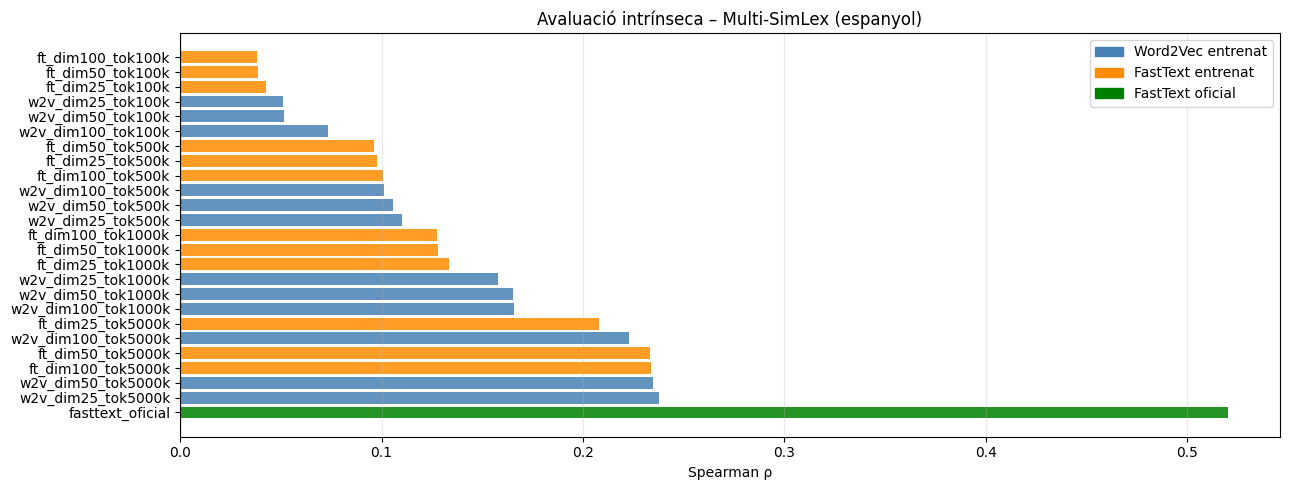

In [25]:
df_res = pd.DataFrame(results).sort_values("spearman", ascending=False)
print(df_res.to_string(index=False))

fig, ax = plt.subplots(figsize=(13, 5))
colors = []
for n in df_res["name"]:
    if n == "fasttext_oficial": colors.append("green")
    elif "w2v" in n:            colors.append("steelblue")
    else:                       colors.append("darkorange")

bars = ax.barh(df_res["name"], df_res["spearman"], color=colors, alpha=0.85)
ax.set_xlabel("Spearman ρ")
ax.set_title("Avaluació intrínseca – Multi-SimLex (espanyol)")
ax.axvline(0, color="black", linewidth=0.8)
ax.grid(axis="x", alpha=0.3)

from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(color="steelblue",   label="Word2Vec entrenat"),
    Patch(color="darkorange",  label="FastText entrenat"),
    Patch(color="green",       label="FastText oficial"),
])
plt.tight_layout()
plt.savefig("grafic_intrinseca.png", dpi=120, bbox_inches="tight")
plt.show()

## 8. Anàlisi: efecte de la dimensió i mida del corpus

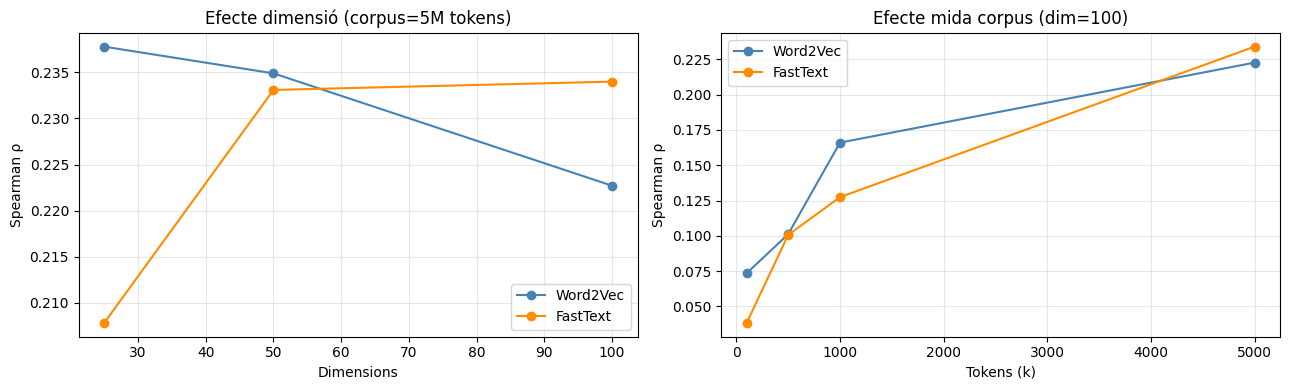

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Efecte dimensió (corpus = 5M)
for model_type, color in [("w2v", "steelblue"), ("ft", "darkorange")]:
    subset = df_res[df_res["name"].str.contains(f"{model_type}_dim") &
                    df_res["name"].str.contains("5000k")]
    dims = subset["name"].str.extract(r"dim(\d+)")[0].astype(int)
    axes[0].plot(dims, subset["spearman"].values, "o-", color=color,
                 label={"w2v": "Word2Vec", "ft": "FastText"}[model_type])
axes[0].set_xlabel("Dimensions"); axes[0].set_ylabel("Spearman ρ")
axes[0].set_title("Efecte dimensió (corpus=5M tokens)")
axes[0].legend(); axes[0].grid(alpha=0.3)

# Efecte corpus (dim = 100)
for model_type, color in [("w2v", "steelblue"), ("ft", "darkorange")]:
    subset = df_res[df_res["name"].str.contains(f"{model_type}_dim100")]
    tokens = subset["name"].str.extract(r"tok(\d+)k")[0].astype(int)
    axes[1].plot(tokens, subset["spearman"].values, "o-", color=color,
                 label={"w2v": "Word2Vec", "ft": "FastText"}[model_type])
axes[1].set_xlabel("Tokens (k)"); axes[1].set_ylabel("Spearman ρ")
axes[1].set_title("Efecte mida corpus (dim=100)")
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("grafic_efectes.png", dpi=120, bbox_inches="tight")
plt.show()